In [3]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('data.csv', encoding='latin1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [6]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(5268)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [9]:
df = df.drop_duplicates()

In [10]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 536641 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    536641 non-null  object 
 1   StockCode    536641 non-null  object 
 2   Description  535187 non-null  object 
 3   Quantity     536641 non-null  int64  
 4   InvoiceDate  536641 non-null  object 
 5   UnitPrice    536641 non-null  float64
 6   CustomerID   401604 non-null  float64
 7   Country      536641 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 36.8+ MB


In [12]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [13]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [14]:
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [15]:
df = df.dropna(subset=['CustomerID'])

In [16]:
df.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [17]:
df.shape

(392692, 8)

In [18]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [19]:
df['CustomerID'].unique

<bound method Series.unique of 0         17850.0
1         17850.0
2         17850.0
3         17850.0
4         17850.0
           ...   
541904    12680.0
541905    12680.0
541906    12680.0
541907    12680.0
541908    12680.0
Name: CustomerID, Length: 392692, dtype: float64>

In [20]:
df['Total Amount'] = df['Quantity'] * df['UnitPrice']

In [21]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total Amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [22]:
df['CustomerID'] = df['CustomerID'].astype(int)

In [23]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Hour'] = df['InvoiceDate'].dt.hour
df['Day'] = df['InvoiceDate'].dt.day_name()

In [24]:
sales_by_day = df.groupby('Day')['Total Amount'].sum().sort_values(ascending=False)

In [25]:
sales_by_day.head()

Day
Thursday     1973015.730
Tuesday      1697733.801
Wednesday    1584283.830
Friday       1483080.811
Monday       1363604.401
Name: Total Amount, dtype: float64

In [26]:
bins = [0, 12, 17, 21, 24]
categories = ['Morning', 'Afternoon', 'Evening', 'Night']
df['Time Period'] = pd.cut(df['Hour'], bins=bins, labels=categories, right=False)

In [27]:
sales_by_tp=df.groupby('Time Period')['Total Amount'].sum().sort_values(ascending = False)

C:\Users\swapn\AppData\Local\Temp\ipykernel_29508\2212727950.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_by_tp=df.groupby('Time Period')['Total Amount'].sum().sort_values(ascending = False)


In [28]:
sales_by_tp.head()

Time Period
Afternoon    4965352.651
Morning      3515898.782
Evening       405957.461
Night              0.000
Name: Total Amount, dtype: float64

In [29]:
df['Day'].unique()

array(['Wednesday', 'Thursday', 'Friday', 'Sunday', 'Monday', 'Tuesday'],
      dtype=object)

In [30]:
df['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Finland',
       'Austria', 'Greece', 'Singapore', 'Lebanon',
       'United Arab Emirates', 'Israel', 'Saudi Arabia', 'Czech Republic',
       'Canada', 'Unspecified', 'Brazil', 'USA', 'European Community',
       'Bahrain', 'Malta', 'RSA'], dtype=object)

C:\Users\swapn\AppData\Local\Temp\ipykernel_29508\2219039362.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


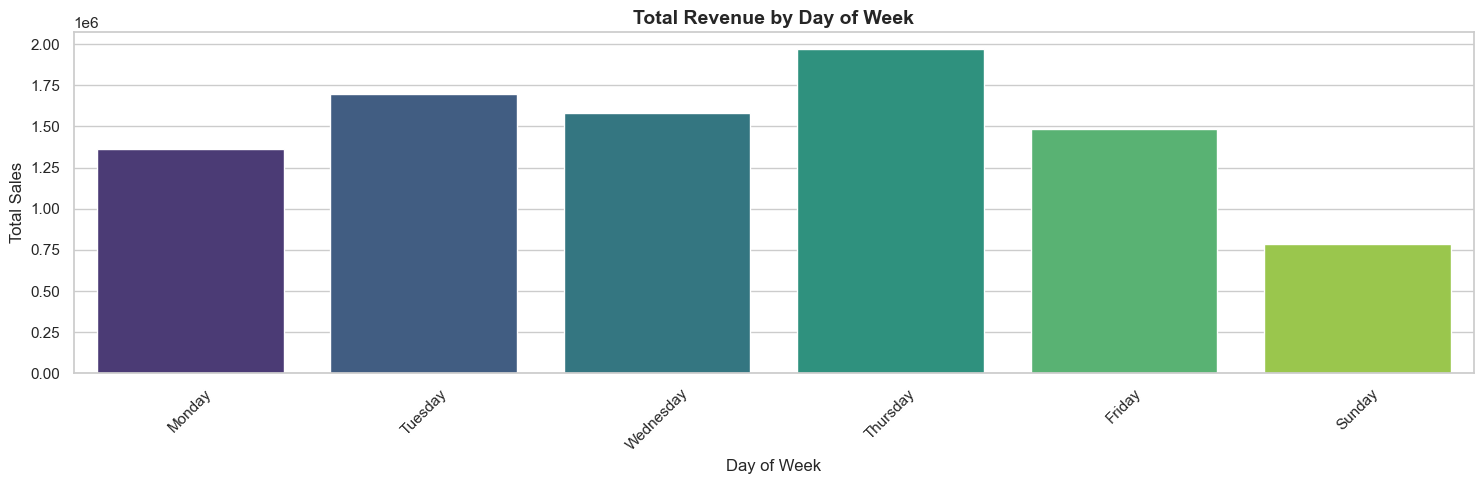

In [31]:

sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday']
sns.barplot(
    data=df, 
    x='Day', 
    y='Total Amount', 
    estimator=sum, 
    order=day_order, 
    errorbar=None, 
    palette='viridis'
)
plt.title('Total Revenue by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

C:\Users\swapn\AppData\Local\Temp\ipykernel_29508\342170119.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


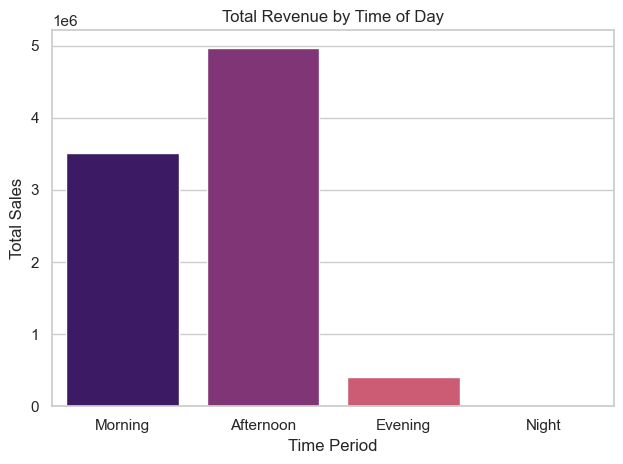

In [32]:
sns.barplot(
    data=df, 
    x='Time Period', 
    y='Total Amount', 
    estimator=sum, 
    errorbar=None, 
    palette='magma'
)
plt.title('Total Revenue by Time of Day')
plt.xlabel('Time Period')
plt.ylabel('Total Sales')

plt.tight_layout()
plt.show()

In [33]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total Amount,Year,Month,Hour,Day,Time Period
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,8,Wednesday,Morning
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,8,Wednesday,Morning
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,8,Wednesday,Morning
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,8,Wednesday,Morning
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,8,Wednesday,Morning


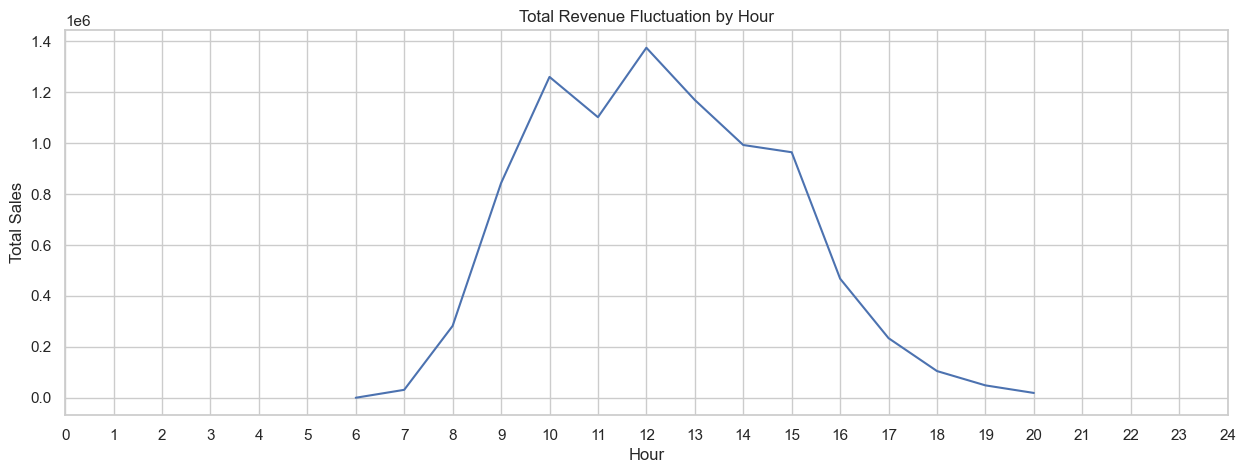

In [35]:
plt.figure(figsize=(15,5))
sns.lineplot(
    data = df,
    x= 'Hour',
    y = 'Total Amount',
    estimator = sum,
    errorbar = None
)

plt.title('Total Revenue Fluctuation by Hour')
plt.xlabel('Hour')
plt.ylabel('Total Sales')
plt.xticks(range(0, 25))
plt.show()


In [36]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total Amount,Year,Month,Hour,Day,Time Period
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,8,Wednesday,Morning
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,8,Wednesday,Morning
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,8,Wednesday,Morning
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,8,Wednesday,Morning
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,8,Wednesday,Morning


In [42]:
country_sales = df.groupby('Country')['Total Amount'].sum().sort_values(ascending = False).reset_index()
country_sales.head()

,Country,Total Amount
0,United Kingdom,7285024.644
1,Netherlands,285446.340
2,EIRE,265262.460
3,Germany,228678.400
4,France,208934.310


In [44]:
country_sales['Percentage'] = (country_sales['Total Amount']/country_sales['Total Amount'].sum())*100
country_sales.head()

,Country,Total Amount,Percentage
0,United Kingdom,7285024.644,81.972020
1,Netherlands,285446.340,3.211878
2,EIRE,265262.460,2.984767
3,Germany,228678.400,2.573118
4,France,208934.310,2.350955


C:\Users\swapn\AppData\Local\Temp\ipykernel_29508\205107590.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_sales[country_sales['Country'] != 'United Kingdom'].head(5),


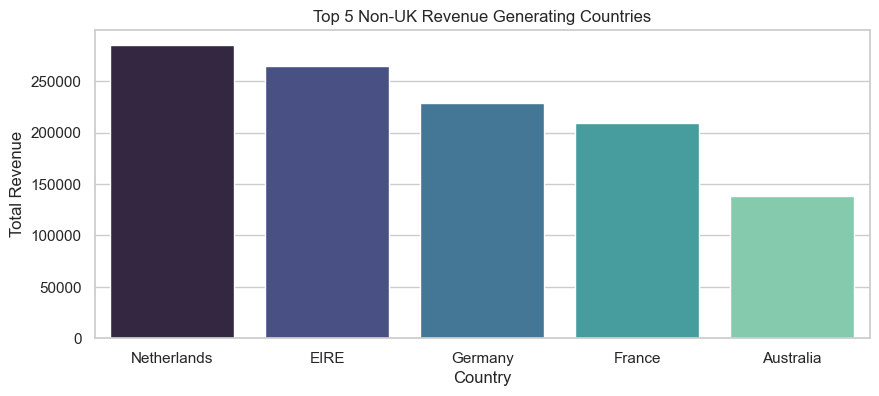

In [50]:
plt.figure(figsize=(10, 4))
sns.barplot(data=country_sales[country_sales['Country'] != 'United Kingdom'].head(5), 
            x='Country', y='Total Amount', palette='mako')
plt.title('Top 5 Non-UK Revenue Generating Countries')
plt.ylabel('Total Revenue')
plt.show()

In [48]:
top_products = df.groupby('Description')['Total Amount'].sum().sort_values(ascending=False).head(10).reset_index()
top_products.head()

,Description,Total Amount
0,"PAPER CRAFT , LITTLE BIRDIE",168469.60
1,REGENCY CAKESTAND 3 TIER,142264.75
2,WHITE HANGING HEART T-LIGHT HOLDER,100392.10
3,JUMBO BAG RED RETROSPOT,85040.54
4,MEDIUM CERAMIC TOP STORAGE JAR,81416.73


C:\Users\swapn\AppData\Local\Temp\ipykernel_29508\3352617458.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, x='Total Amount', y='Description', palette='rocket')


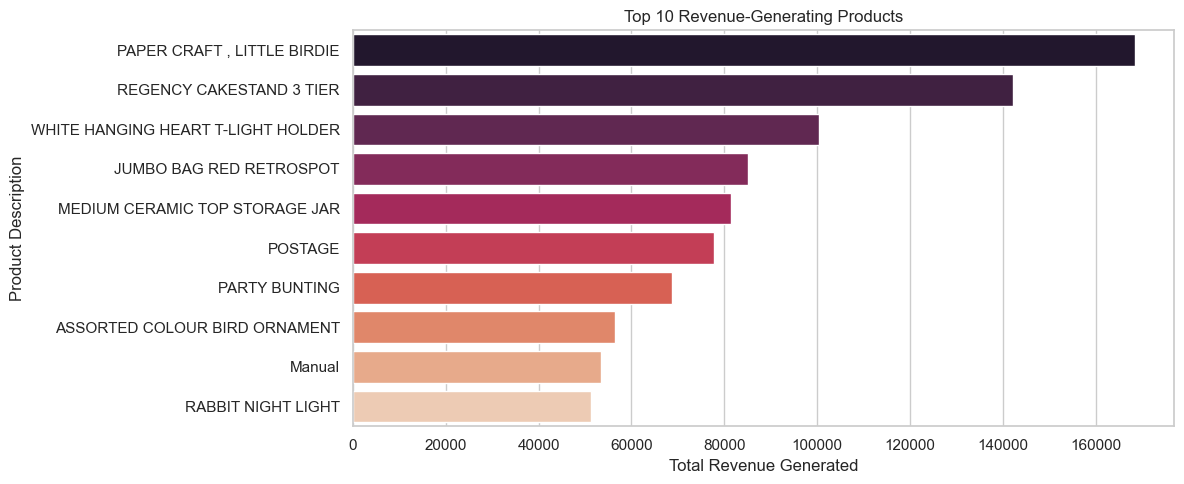

In [49]:
plt.figure(figsize=(12, 5))
sns.barplot(data=top_products, x='Total Amount', y='Description', palette='rocket')
plt.title('Top 10 Revenue-Generating Products')
plt.xlabel('Total Revenue Generated')
plt.ylabel('Product Description')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
categorical_cols = ['Day', 'Time Period']
df_encoded = pd.get_dummies(df, columns=categorical_cols, dtype=int)
df_encoded.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total Amount,Year,...,Day_Friday,Day_Monday,Day_Sunday,Day_Thursday,Day_Tuesday,Day_Wednesday,Time Period_Morning,Time Period_Afternoon,Time Period_Evening,Time Period_Night
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,...,0,0,0,0,0,1,1,0,0,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,...,0,0,0,0,0,1,1,0,0,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,...,0,0,0,0,0,1,1,0,0,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,...,0,0,0,0,0,1,1,0,0,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,...,0,0,0,0,0,1,1,0,0,0


In [ ]:
numerical_cols = ['Quantity', 'UnitPrice', 'Total Amount']
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_encoded[numerical_cols])
scaled_features



array([[-0.03944595, -0.02589331, -0.02356647],
       [-0.03944595,  0.01187341, -0.00736583],
       [-0.02836516, -0.01690123, -0.0020299 ],
       ...,
       [-0.05052674,  0.04604329, -0.01938773],
       [-0.05052674,  0.04604329, -0.01938773],
       [-0.05606713,  0.0820116 , -0.02501295]], shape=(392692, 3))

In [61]:
df_encoded[[col + '_scaled' for col in numerical_cols]] = scaled_features

In [62]:
df_encoded.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total Amount,Year,...,Day_Thursday,Day_Tuesday,Day_Wednesday,Time Period_Morning,Time Period_Afternoon,Time Period_Evening,Time Period_Night,Quantity_scaled,UnitPrice_scaled,Total Amount_scaled
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,...,0,0,1,1,0,0,0,-0.039446,-0.025893,-0.023566
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,...,0,0,1,1,0,0,0,-0.039446,0.011873,-0.007366
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,...,0,0,1,1,0,0,0,-0.028365,-0.016901,-0.002030
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,...,0,0,1,1,0,0,0,-0.039446,0.011873,-0.007366
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,...,0,0,1,1,0,0,0,-0.039446,0.011873,-0.007366


In [63]:
columns_to_drop = [
    'InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 
    'CustomerID', 'Country', 'Quantity', 'UnitPrice', 'Total Amount'
]

final_drop_list = [col for col in columns_to_drop if col in df_encoded.columns]

X = df_encoded.drop(columns=final_drop_list)

In [66]:
print("Remaining Column Data Types:")
print(X.dtypes.value_counts())

Remaining Column Data Types:
int64      10
int32       3
float64     3
Name: count, dtype: int64


In [67]:
X.to_csv('cleaned_ml_features.csv', index=False)